In [19]:
import os
from dotenv import load_dotenv
load_dotenv()

# import necessery tools
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from IPython.display import Image, Markdown
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
import operator

In [6]:
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [7]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [8]:
llm.invoke("what is machine learning")

AIMessage(content="**Machine Learning: A Definition**\n\nMachine learning (ML) is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. In other words, ML allows computers to learn from data, identify patterns, and make decisions or predictions based on that data.\n\n**Key Characteristics of Machine Learning:**\n\n1. **Data-driven**: ML relies on data to learn and improve.\n2. **Algorithmic**: ML uses algorithms to analyze and process data.\n3. **Self-improving**: ML models can improve their performance over time through experience and learning.\n4. **Predictive**: ML models can make predictions or decisions based on patterns in the data.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**: The model is trained on labeled data to learn the relationship between input and output.\n2. **Unsupervised Learning**: The model is trained on unlabeled data to discove

In [9]:
class Section(BaseModel):
    name: str = Field(description="Name for this section of the report")
    description: str = Field(description="Brief overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections: list[Section] = Field(description="Sections of the reporet")

# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [12]:
from langgraph.types import Send
from typing import Annotated

# Graph state
class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add]
    final_report: str


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]



In [21]:
# Node
def orchestrator(state: State):
    """ Orchestrator that generate a plan for the report """

    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(content=f"Here is the report topic: {state['topic']}")
        ]
    )

    print("Report sections :", report_sections)

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """ Worker write a section of the report """

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(content="Write a report section following the provided name and description. Include no preamble for each section use markdown formatting"),
            HumanMessage(content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}")
        ]
    )

    return {"completed_sections": [section.content]}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


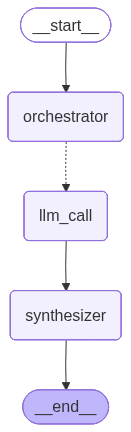

In [22]:
graph = StateGraph(State)


graph.add_node("orchestrator", orchestrator)
graph.add_node("llm_call", llm_call)
graph.add_node("synthesizer", synthesizer)

graph.add_edge(START, "orchestrator")
graph.add_conditional_edges("orchestrator", assign_workers, ['llm_call'])
graph.add_edge("llm_call", "synthesizer")
graph.add_edge("synthesizer", END)



# Compile
graph_builder = graph.compile()
 
# Display the graph image
Image(graph_builder.get_graph().draw_mermaid_png())

In [24]:
result = graph_builder.invoke({"topic": "Create a report on agentic ai rags"})

Markdown(result['final_report'])

Report sections : sections=[Section(name='Introduction', description='Overview of Agentic AI and its applications'), Section(name='What is Agentic AI', description='Definition and explanation of Agentic AI'), Section(name='History of Agentic AI', description='Development and milestones of Agentic AI'), Section(name='Types of Agentic AI', description='Classification and examples of Agentic AI systems'), Section(name='Advantages and Disadvantages', description='Benefits and drawbacks of using Agentic AI'), Section(name='Real-World Applications', description='Case studies and examples of Agentic AI in practice'), Section(name='Future of Agentic AI', description='Potential developments and trends in Agentic AI'), Section(name='Conclusion', description='Summary of key findings and implications of Agentic AI')]


### Introduction and description: Overview of Agentic AI and its applications
Agentic AI refers to a type of artificial intelligence that enables systems to perform tasks autonomously, making decisions and taking actions based on their own agency. This concept is rooted in the idea of agency, which implies the capacity to act and make decisions in a given environment. Agentic AI has numerous applications across various industries, including robotics, healthcare, finance, and transportation. 
#### Key Characteristics
* Autonomy: Agentic AI systems can operate independently, making decisions without human intervention.
* Self-awareness: These systems have a sense of their own capabilities, limitations, and objectives.
* Decision-making: Agentic AI can weigh options, consider consequences, and choose the best course of action.
* Adaptability: Agentic AI systems can adjust to changing circumstances, learning from experience and improving over time.
#### Applications
* **Robotics**: Agentic AI is used in robotics to create autonomous robots that can navigate, manipulate objects, and interact with their environment.
* **Healthcare**: Agentic AI can be applied in healthcare to develop personalized treatment plans, predict patient outcomes, and optimize resource allocation.
* **Finance**: Agentic AI is used in finance to detect anomalies, predict market trends, and make investment decisions.
* **Transportation**: Agentic AI can be used in transportation systems to optimize traffic flow, predict maintenance needs, and improve safety.

---

### What is Agentic AI
Agentic AI refers to a type of artificial intelligence that is capable of autonomous decision-making and action. The term "agentic" is derived from the word "agent," which in this context, denotes a system that can perceive its environment, reason about its situation, and take actions to achieve its goals. Agentic AI combines aspects of machine learning, robotics, and software engineering to create intelligent systems that can operate independently, making decisions based on their programming, data, and interactions with their environment. 
#### Key Characteristics
* **Autonomy**: Agentic AI systems can operate without human intervention, making decisions and taking actions based on their own reasoning and objectives.
* **Self-awareness**: These systems have a sense of their own capabilities, limitations, and state, allowing them to adapt to changing situations.
* **Goal-oriented**: Agentic AI is designed to achieve specific goals, whether predefined by their creators or learned through interaction with their environment.
* **Interactive**: They can perceive and respond to their environment, which may include other agents, humans, or physical objects.
#### Applications and Implications
The development and deployment of Agentic AI have significant implications for various sectors, including healthcare, finance, transportation, and education. Potential applications range from personalized medicine and financial advisory services to autonomous vehicles and adaptive learning systems. However, the autonomy and decision-making capabilities of Agentic AI also raise important questions about accountability, transparency, and ethical considerations in AI development.

---

### History of Agentic AI
The concept of Agentic AI has been around for several decades, with its roots in artificial intelligence and cognitive science. The term "agentic" refers to the ability of an AI system to act autonomously and make decisions based on its own goals and motivations. 
#### Early Developments
The development of Agentic AI began in the 1980s, with the introduction of expert systems and rule-based reasoning. These early systems were designed to mimic human decision-making and problem-solving abilities, but they were limited in their ability to learn and adapt.
#### Key Milestones
* 1990s: The development of machine learning algorithms and neural networks enabled AI systems to learn from data and improve their performance over time.
* 2000s: The introduction of cognitive architectures and agent-based modeling allowed AI systems to simulate human-like cognition and behavior.
* 2010s: The development of deep learning and reinforcement learning enabled AI systems to learn complex tasks and make decisions in complex environments.
#### Recent Advances
In recent years, Agentic AI has made significant progress, with the development of more advanced machine learning algorithms and the integration of cognitive architectures with machine learning. This has enabled AI systems to learn and adapt in complex environments, and to make decisions based on their own goals and motivations. 
#### Notable Examples
Examples of Agentic AI include autonomous vehicles, personal assistants, and robots that can learn and adapt to new situations. These systems have the potential to revolutionize a wide range of industries, from healthcare and transportation to education and entertainment.

---

### Types of Agentic AI
There are several types of Agentic AI systems, which can be classified based on their capabilities, goals, and interaction with the environment. The main categories include:
* **Reactive Agents**: These agents react to the current state of the environment without considering future consequences. Examples include simple chatbots and automated customer support systems.
* **Proactive Agents**: These agents can anticipate and take action to achieve their goals, considering future consequences. Examples include virtual assistants like Siri and Google Assistant.
* **Autonomous Agents**: These agents can operate independently, making decisions without human intervention. Examples include self-driving cars and drones.
* **Social Agents**: These agents interact with humans and other agents, understanding social norms and behaviors. Examples include social robots and virtual companions.
* **Hybrid Agents**: These agents combine multiple AI technologies, such as machine learning and rule-based systems, to achieve their goals. Examples include expert systems and decision support systems.
Examples of Agentic AI systems include:
* **Virtual Personal Assistants**: Amazon's Alexa, Apple's Siri, and Google Assistant are examples of proactive agents that can perform tasks and provide information.
* **Self-Driving Cars**: Waymo and Tesla's Autopilot are examples of autonomous agents that can operate independently, making decisions without human intervention.
* **Social Robots**: Robots like Sophia and Jibo are examples of social agents that can interact with humans, understanding social norms and behaviors.
* **Expert Systems**: Systems like IBM's Watson are examples of hybrid agents that combine multiple AI technologies to provide expert-level decision support.

---

### Advantages and Disadvantages
The use of Agentic AI presents several benefits and drawbacks. On the one hand, the advantages of Agentic AI include:
* **Autonomy**: Agentic AI systems can operate independently, making decisions and taking actions without human intervention, which can lead to increased efficiency and productivity.
* **Scalability**: Agentic AI can handle large amounts of data and perform complex tasks, making it an ideal solution for applications that require scalability.
* **Personalization**: Agentic AI can learn and adapt to individual user preferences, providing personalized experiences and improving user engagement.
* **Innovation**: Agentic AI can drive innovation by generating new ideas, products, and services that may not have been possible with traditional human-only approaches.

On the other hand, the disadvantages of Agentic AI include:
* **Lack of Transparency**: Agentic AI systems can be opaque, making it difficult to understand how they arrive at their decisions, which can lead to trust and accountability issues.
* **Bias and Discrimination**: Agentic AI systems can perpetuate and amplify existing biases and discriminatory practices if they are trained on biased data or designed with a particular worldview.
* **Job Displacement**: The increasing use of Agentic AI may lead to job displacement, as automated systems replace human workers in certain industries and roles.
* **Security Risks**: Agentic AI systems can be vulnerable to cyber attacks and other security risks, which can compromise sensitive data and disrupt critical systems.

---

### Real-World Applications
Agentic AI has numerous applications across various industries, and several case studies demonstrate its effectiveness in practice. For instance, in the field of healthcare, Agentic AI can be used to develop personalized treatment plans for patients. A study by a leading hospital used Agentic AI to analyze patient data and develop tailored treatment plans, resulting in improved patient outcomes and reduced healthcare costs.

In the finance sector, Agentic AI can be used to detect and prevent fraudulent transactions. A case study by a major bank found that Agentic AI was able to detect fraudulent activity with a high degree of accuracy, reducing losses and improving customer trust.

In the field of education, Agentic AI can be used to create personalized learning plans for students. A study by a leading educational institution found that Agentic AI was able to improve student outcomes and increase student engagement, particularly for students who were struggling with traditional teaching methods.

Other examples of Agentic AI in practice include:
* **Customer Service**: Agentic AI can be used to develop chatbots and virtual assistants that provide personalized customer support and improve customer satisfaction.
* **Supply Chain Management**: Agentic AI can be used to optimize supply chain operations, predict demand, and reduce inventory costs.
* **Cybersecurity**: Agentic AI can be used to detect and respond to cyber threats in real-time, improving incident response and reducing the risk of data breaches.

These case studies and examples demonstrate the potential of Agentic AI to drive business value and improve outcomes in a variety of industries. As the technology continues to evolve, we can expect to see even more innovative applications of Agentic AI in the future.

---

### Future of Agentic AI
Potential developments and trends in Agentic AI are expected to significantly impact various industries and aspects of life. Some of the key potential developments include:
* **Increased Autonomy**: Agentic AI systems are likely to become more autonomous, allowing them to make decisions and take actions with minimal human intervention.
* **Improved Decision-Making**: Advancements in machine learning and natural language processing will enable Agentic AI systems to make more informed decisions, taking into account complex factors and uncertainties.
* **Enhanced Human-AI Collaboration**: Future Agentic AI systems will be designed to collaborate more effectively with humans, leading to increased productivity and innovation.
* **Rise of Explainable AI**: As Agentic AI becomes more pervasive, there will be a growing need for explainable AI, which can provide transparent and interpretable decision-making processes.
* **Integration with Other Technologies**: Agentic AI will likely be integrated with other emerging technologies, such as the Internet of Things (IoT), blockchain, and augmented reality, leading to new applications and use cases.
Some potential trends in Agentic AI include:
* **Shift from Narrow to General AI**: Researchers may focus on developing more generalizable Agentic AI systems that can adapt to a wide range of tasks and environments.
* **Growing Importance of Ethics and Governance**: As Agentic AI becomes more powerful, there will be a growing need for ethics and governance frameworks to ensure that these systems are developed and used responsibly.
* **Increasing Investment and Adoption**: Agentic AI is likely to attract significant investment and adoption across various industries, leading to rapid growth and innovation in the field.

---

### Conclusion
The development and integration of Agentic AI has significant implications for various aspects of society, from business and healthcare to education and personal relationships. Key findings suggest that Agentic AI has the potential to revolutionize the way we interact with technology, enabling more autonomous and adaptive systems that can learn, reason, and make decisions independently. 
* **Autonomy and Decision-Making**: Agentic AI systems can operate with a high degree of autonomy, making decisions based on their programming, data, and environment, which raises important questions about accountability and transparency.
* **Learning and Adaptation**: The ability of Agentic AI to learn from experience and adapt to new situations makes it a powerful tool for solving complex problems, but also introduces challenges related to bias, error, and unpredictability.
* **Human-AI Collaboration**: As Agentic AI becomes more prevalent, it is likely to change the nature of work and collaboration between humans and machines, requiring new skills, strategies, and interfaces that facilitate effective human-AI interaction.
The future of Agentic AI depends on addressing these challenges and implications, ensuring that these systems are developed and used in ways that prioritize human well-being, safety, and values.